In [ ]:
# mAP는 모델의 정확도를 평가하는 지표로, 모델이 얼마나 정확하게 객체를 감지하는지를 나타냅니다. 
# mAP는 모델이 감지한 객체와 실제 객체 간의 일치 정도를 측정하여 계산됩니다.
# 높은 mAP 값은 모델이 객체를 정확하게 감지하는 능력이 뛰어나다는 것을 의미합니다. 
# mAP는 일반적으로 0에서 1 사이의 값으로 표현되며, 1에 가까울수록 모델의 성능이 좋다고 평가됩니다.

# MMDetection은 객체 감지 모델을 개발하고 평가하기 위한 오픈소스 라이브러리입니다. 
# MMDetection은 다양한 객체 감지 모델과 알고리즘을 지원하며, 모델의 성능을 평가하기 위한 다양한 지표를 제공합니다. 
# MMDetection을 사용하여 모델의 mAP를 계산할 수 있습니다.

# 이미지 감지 후 결과 출력
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import os


model = YOLO("yolo11n.pt")

image_path = "./yolo_imgs/image1.jpg"
image = cv2.imread(image_path)

results = model(image)
# 더 높은 confidence 기준
# results = model(image, conf=0.8)  # confidence threshold를 0.5로 설정

if image is None:
    print("이미지를 불러올 수 없습니다.")
    exit()

results = model(image)
print(results)


0: 416x640 2 persons, 14.7ms
Speed: 4.1ms preprocess, 14.7ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 2 persons, 14.6ms
Speed: 2.0ms preprocess, 14.6ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine

감지된 총 사람 수: 2


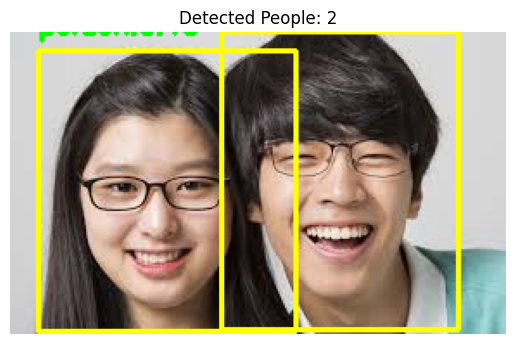

결과 이미지가 'yolo3output.jpg'에 저장되었습니다.


In [57]:
# 원본 이미지 별도 기억
original_image = image.copy()

person_count = 0

for result in results:
    for box in result.boxes:
        # 바운딩 박스 좌표 추출
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 클래스 라벨 추출
        label = result.names[int(box.cls[0])]

        # 신뢰도 추출
        confidence = box.conf[0].item()

        # 사람인 경우 카운트 증가
        if label.lower() == "person":
            person_count += 1

        # 바운딩 박스 그리기
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)        # 초록색 바운딩박스, 두께 2

        # 라벨과 신뢰도 표시
        text = f"{label}:{confidence:.2f}"
        cv2.putText(image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 결과 출력
print(f"감지된 총 사람 수: {person_count}")

# 이미지 출력
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))      # BGR : OpenCV의 기본 색상 형식, RGB : Matplotlib의 기본 색상 형식
plt.axis('off')
plt.title(f"Detected People: {person_count}")
plt.show()


# 결과 저장
output_path = "yolo3output.jpg"
cv2.imwrite(output_path, image)
print(f"결과 이미지가 '{output_path}'에 저장되었습니다.")

In [58]:
print("바운딩 박스 좌표 출력")
for result in results:
    for box in result.boxes:
        label, confidence = result.names[int(box.cls[0])], box.conf[0].item()
        print(f"라벨: {label}\t\t신뢰도: {confidence:.2f}\t\t좌표: ({int(box.xyxy[0][0])},{int(box.xyxy[0][1])})\t({int(box.xyxy[0][2])},{int(box.xyxy[0][3])})")

바운딩 박스 좌표 출력
라벨: person		신뢰도: 0.82		좌표: (122,0)	(259,172)
라벨: person		신뢰도: 0.46		좌표: (16,11)	(165,173)


In [59]:
9# 신뢰도 높은 객체만 필터링 (예 : 70% 이상)
for idx, result in enumerate(results):
    print(f"전체 라벨 순서 중, 이미지 {idx}번째 결과")

    # 신뢰도 70% 이상인 객체가 있는지 여부를 추적하는 변수 flag
    found = False

    # 신뢰도 70% 이상인 객체만 출력
    for box in result.boxes:
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if confidence >= 0.7:
            found = True
            print(f"  라벨: {label},\t신뢰도: {confidence:.2f},\t좌표: ({x1},{y1}),({x2},{y2})")
    
    # 신뢰도 70% 이상인 객체가 없는 경우 메시지 출력
    if not found:
        print("  신뢰도 70% 이상인 객체가 없습니다.")

전체 라벨 순서 중, 이미지 0번째 결과
  라벨: person,	신뢰도: 0.82,	좌표: (122,0),(259,172)


In [73]:
# 바운딩 박스 내부 객체 저장 1 (바운딩 박스 내부 객체를 별도의 이미지로 저장)
for idx, result in enumerate(results):
    print(f"전체 라벨 순서 중, 이미지 {idx}번째 결과")

    for j, box in enumerate(result.boxes):
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 이미지에서 ROI(Region of Interest) 추출
        cropped_image = original_image[y1:y2, x1:x2]
        output_cropped_path = f"cropped_{idx}_{j}_{label}.jpg"
        cv2.imwrite(output_cropped_path, cropped_image)
        print(f"  라벨: {label},\t신뢰도: {confidence:.2f},\t좌표: ({x1},{y1}),({x2},{y2})")
        print(f"  바운딩 박스 내부 객체가 '{output_cropped_path}'에 저장되었습니다.")

# 바운딩 박스 내부 객체 저장 2 (바운딩 박스 없이 객체를 별도의 이미지로 저장)
os.makedirs("cropped_objects", exist_ok=True)  # 저장 폴더 생성

for idx, result in enumerate(results):
    print(f"전체 라벨 순서 중, 이미지 {idx}번째 결과")

    for j, box in enumerate(result.boxes):
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 이미지에서 ROI(Region of Interest) 추출
        cropped_image = original_image[y1:y2, x1:x2]

        # 바운딩 박스 없이 객체 저장
        output_cropped_path = f"cropped_objects/cropped_{idx}_{j}_{label}.jpg"
        cv2.imwrite(output_cropped_path, cropped_image)
        print(f"  라벨: {label},\t신뢰도: {confidence:.2f},\t좌표: ({x1},{y1}),({x2},{y2})")
        print(f"  바운딩 박스 내부 객체가 '{output_cropped_path}'에 저장되었습니다.")

전체 라벨 순서 중, 이미지 0번째 결과
  라벨: person,	신뢰도: 0.82,	좌표: (122,0),(259,172)
  바운딩 박스 내부 객체가 'cropped_0_0_person.jpg'에 저장되었습니다.
  라벨: person,	신뢰도: 0.46,	좌표: (16,11),(165,173)
  바운딩 박스 내부 객체가 'cropped_0_1_person.jpg'에 저장되었습니다.
전체 라벨 순서 중, 이미지 0번째 결과
  라벨: person,	신뢰도: 0.82,	좌표: (122,0),(259,172)
  바운딩 박스 내부 객체가 'cropped_objects/cropped_0_0_person.jpg'에 저장되었습니다.
  라벨: person,	신뢰도: 0.46,	좌표: (16,11),(165,173)
  바운딩 박스 내부 객체가 'cropped_objects/cropped_0_1_person.jpg'에 저장되었습니다.


총 감지된 사람 수: 1, 중심좌표 : (190,86), 신뢰도 : 0.82
총 감지된 사람 수: 2, 중심좌표 : (90,92), 신뢰도 : 0.46


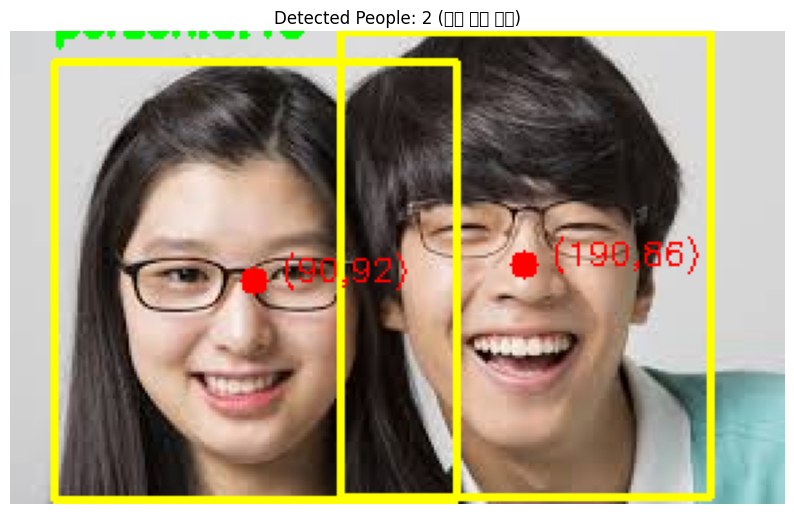

In [84]:
# 감지된 객체의 중심 좌표 출력 + 시각화
person_count = 0


for result in results:
    for box in result.boxes:
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 중심 좌표 계산
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2

        # 사람인 경우 카운트 증가
        if label.lower() == "person":
            person_count += 1
            print(f"총 감지된 사람 수: {person_count}, 중심좌표 : ({center_x},{center_y}), 신뢰도 : {confidence:.2f}")

            # 중심 좌표 시각화
            cv2.circle(image, (center_x, center_y), 5, (0, 0, 255), -1)  # 빨간색 점으로 중심 표시
            cood_text = f"({center_x},{center_y})"
            cv2.putText(image, cood_text, (center_x + 10, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        
            # 바운딩박스 출력
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)        # 초록색 바운딩박스, 두께 2
            cv2.putText(image, f"{label}:{confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Detected People: {person_count} (중심 좌표 포함)")
plt.show()


0: 640x640 2 persons, 21.5ms
1: 640x640 3 persons, 1 handbag, 21.5ms
2: 640x640 5 persons, 2 cars, 1 motorcycle, 21.5ms
Speed: 11.9ms preprocess, 21.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

이미지 0 ./yolo_imgs/image1.jpg 결과:
 -person 0.78
 -person 0.43

이미지 1 ./yolo_imgs/image2.jpg 결과:
 -person 0.83
 -person 0.73
 -handbag 0.45

이미지 2 ./yolo_imgs/image3.jpg 결과:
 -person 0.87
 -person 0.87
 -motorcycle 0.85
 -person 0.68


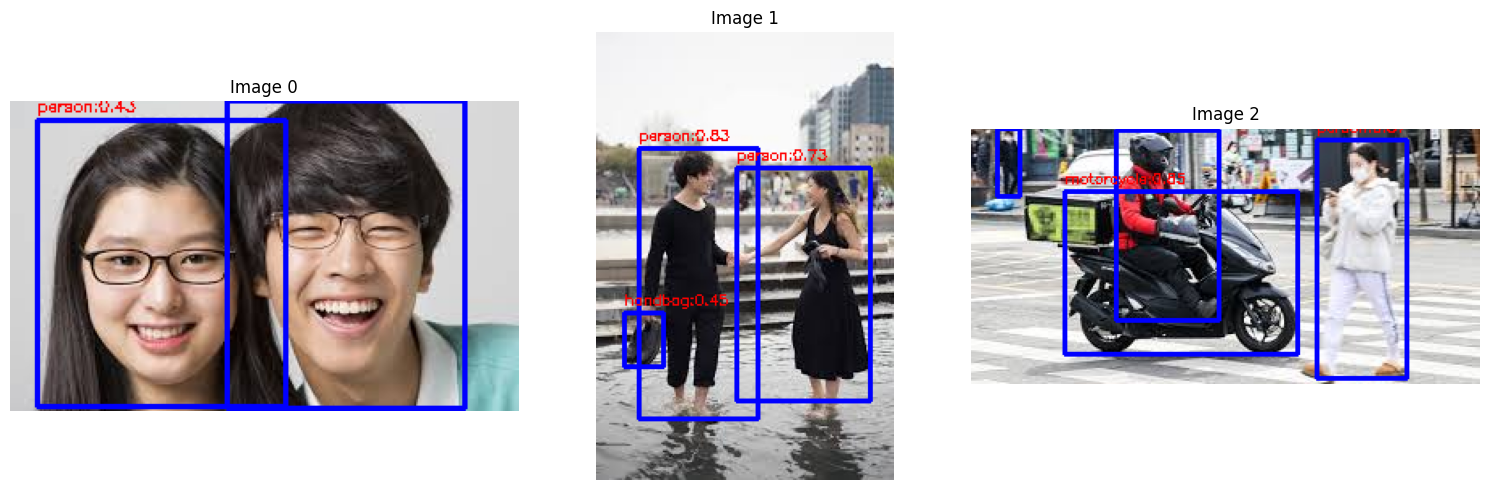

In [95]:
# 복수 이미지 처리
image_paths = ["./yolo_imgs/image1.jpg", "./yolo_imgs/image2.jpg", "./yolo_imgs/image3.jpg"]
results = model(image_paths)

# 시각화
fig, axis = plt.subplots(1, len(image_paths), figsize=(15, 5))
for idx, (result, img_path) in enumerate(zip(results, image_paths)):        # zip() 함수를 사용하여 results와 image_paths를 동시에 순회, enumrate() 함수를 사용하여 인덱스와 결과를 함께 가져옴
    print(f"\n이미지 {idx} {img_path} 결과:")
    
    # 찾았다는 flag 변수
    found = False

    # 원본 이미지 불러오기
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)                              # OpenCV는 BGR 형식이므로 RGB로 변환
    
    # 바운딩 박스 그리기 및 라벨 표시
    for box in result.boxes:
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()

        # 신뢰도 40% 이상인 객체가 있는지 여부를 추적하는 변수 flag
        if confidence >= 0.4:
            print(f" -{label} {confidence:.2f}")
            found = True

            # 바운딩 박스 좌표 추출
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # 바운딩 박스 그리기
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)        # 초록색 바운딩박스, 두께 2
            cv2.putText(img, f"{label}:{confidence:.2f}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)
    if not found:
        print(" - 신뢰도 40% 이상인 객체가 없습니다.")
    
    axis[idx].imshow(img)
    axis[idx].axis('off')
    axis[idx].set_title(f"Image {idx}")

plt.tight_layout()
plt.show()


